In [1]:
from parser import Parser
import shapely
from shapely.ops import transform
import osmnx as ox
import geopandas as gpd
import pathlib
import os


import networkx as nx
import numpy as np
from shapely.geometry import LineString, Point
import math
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

import numpy.typing as npt

from scipy.spatial import cKDTree
from shapely.strtree import STRtree

from shapely.geometry import LineString
import math




In [2]:
MERCATOR = 3857
WGS_84 = 4326

In [3]:
save_dir = pathlib.Path("/mnt/c/Users/nikita/qgisData/busroutes")
save_dir.mkdir(parents=True, exist_ok=True)

In [4]:
with open("input/boundaries.geojson", "r") as f:
    geojson = f.read()
boundaries = shapely.from_geojson(geojson)
graph = ox.graph_from_polygon(boundaries, network_type="drive", simplify=False)
nodes, edges = ox.graph_to_gdfs(graph)


# convert crs to mercator
nodes = nodes.to_crs(epsg=MERCATOR)
edges = edges.to_crs(epsg=MERCATOR)

In [5]:
bus_parser = Parser.BusGraphParser("Санкт-Петербург")
_example_route = bus_parser.get_route("/spb/bus/61")

# convert to mercator
example_route_series = gpd.GeoSeries([Point(y, x) for x, y in _example_route], crs=WGS_84).to_crs(epsg=MERCATOR)
example_route_series


read https://kudikina.ru/spb/bus/61/map from cache


0      POINT (3394516.106 8401817.854)
1      POINT (3394524.566 8401795.807)
2      POINT (3394527.349 8401787.567)
3      POINT (3394531.468 8401772.646)
4       POINT (3394537.256 8401754.83)
                    ...               
430    POINT (3394544.047 8401737.682)
431    POINT (3394570.096 8401771.978)
432    POINT (3394572.099 8401806.051)
433     POINT (3394563.751 8401819.19)
434     POINT (3394539.483 8401810.06)
Length: 435, dtype: geometry

In [6]:
geoms = edges["geometry"]
rtree = STRtree(edges["geometry"])


In [7]:
def calc_angle_dot_product(a: npt.NDArray, b: npt.NDArray) -> float:
    """
    Calculate the angle between two vectors using the dot product formula.
    """
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return np.dot(a, b)

In [99]:
def snap_point_to_best_edge(gr_edges, idxtree, route_part, distance_tol=0.0004):
    
    edge_idx = idxtree.query(route_part.buffer(distance_tol))
    edge_candidates = geoms.iloc[edge_idx].index.to_numpy()
    # Pick the best matching edge
    best_match = None
    

    for u, v, key in edge_candidates:
        edge = gr_edges.loc[(u, v, key)]
        edge_geom = edge['geometry']
        edge_geom = LineString(edge_geom)
        
        
        # calc angle bween route and edge as angle between two vectors using dot product
        dot_prod = calc_angle_dot_product(
            np.array(route_part.coords[0]) - np.array(route_part.coords[1]),
            np.array(edge_geom.coords[0]) - np.array(edge_geom.coords[1])
        )
        # find best dot product 
        if best_match is None or dot_prod > best_match[0]:
            best_match = (dot_prod, edge)
    
            
    if not best_match:
        return None
    if best_match[0] < 0.5:
        return None
    print("best match", best_match[0])
    return best_match[1]

In [100]:
buf_tol = 20
ln = LineString([example_route_series.iloc[6], example_route_series.iloc[7]])
buf = ln.buffer(buf_tol)
hm = rtree.query(buf)
with open(save_dir/"linebuf.geojson", "w") as f:
    f.write(shapely.to_geojson(buf))
ne_array = geoms.iloc[hm].index.to_numpy()
ne_array
matchedges = edges.loc[ne_array]
with open(save_dir / "matchedges.geojson", "w") as f:
    f.write(matchedges.to_json())
mat = snap_point_to_best_edge(edges, rtree, LineString([example_route_series.iloc[6], example_route_series.iloc[7]]), distance_tol=buf_tol)
mat

best match 0.9999992738688882


osmid                                               133743584
highway                                              tertiary
junction                                                  NaN
lanes                                                       2
maxspeed                                             RU:rural
name                                         Челябинский мост
oneway                                                  False
reversed                                                 True
length                                             117.629495
ref                                                       NaN
bridge                                                    yes
width                                                     NaN
tunnel                                                    NaN
access                                                    NaN
geometry    LINESTRING (3394368.9302678057 8401644.7723769...
in_route                                                 True
Name: (2

In [101]:
matched_edges = []
for i in range(len(example_route_series) - 1):
    pt1 = example_route_series.iloc[i]
    pt2 = example_route_series.iloc[i + 1]
    route_part = LineString([pt1, pt2])
    match = snap_point_to_best_edge(edges, rtree, route_part, buf_tol)
    if match is not None:
        matched_edges.append(match.name)

best match 0.9999856609685347
best match 0.9999992738688882
best match 0.9999926786464554
best match 0.9994603248363099
best match 0.9989559020691631
best match 0.8763192777501124
best match 0.9951887390380784
best match 0.9999803592407228
best match 0.9979693679381731
best match 0.9908328646924445
best match 0.9498507302842266
best match 0.9613307301934935
best match 0.9998237365502174
best match 0.9989947520680823
best match 0.9983104470610514
best match 0.9999966578650311
best match 0.9992121478950611
best match 0.9997787416902438
best match 0.9982160607232952
best match 0.999920028816997
best match 0.999751754193063
best match 0.9999306254096372
best match 0.9999692930626707
best match 0.9999910613911689
best match 0.5902695301530738
best match 0.6982779998401007
best match 0.9999822792627627
best match 0.9999999981359284
best match 0.9999625461140286
best match 0.9999988538444469
best match 0.9993137732582814
best match 0.9999999670672787
best match 0.9999882455276663
best match 0

In [102]:
edges.loc[matched_edges, "in_route"] = True

In [103]:
matched_edges_arr = np.array(matched_edges)
_, un_idx = np.unique(matched_edges_arr, axis=0, return_index=True)
un_idx_sorted = np.sort(un_idx)

In [104]:
filtered_matched_edges_arr = matched_edges_arr[np.sort(un_idx)]
filtered_matched_edges_arr

array([[ 9122784650,      245837,           0],
       [     245837,    26239931,           0],
       [   26239931,  7934509667,           0],
       [ 7934509667,  1472028015,           0],
       [ 2293554055,  4226081644,           0],
       [ 1095791784,  4226081644,           0],
       [ 4226081644,  8776518267,           0],
       [ 8776518267,  8776518268,           0],
       [ 8776518268,  8776518269,           0],
       [11063930966,  8776518270,           0],
       [ 9986275005,  8549140532,           0],
       [ 8549140532,  8549140533,           0],
       [ 8549140531,  8549140537,           0],
       [ 8549140538,  8549160376,           0],
       [ 8549160376,  8549160377,           0],
       [ 7326390789,  7015071225,           0],
       [ 7015071225,  6940404524,           0],
       [ 7326390790,  7015071222,           0],
       [ 7015071222,  7323620850,           0],
       [ 6940404507,  9983811802,           0],
       [11063930976,  9978613422,       

In [105]:
matched_edges

[(np.int64(9122784650), np.int64(245837), np.int64(0)),
 (np.int64(245837), np.int64(26239931), np.int64(0)),
 (np.int64(26239931), np.int64(7934509667), np.int64(0)),
 (np.int64(7934509667), np.int64(1472028015), np.int64(0)),
 (np.int64(2293554055), np.int64(4226081644), np.int64(0)),
 (np.int64(1095791784), np.int64(4226081644), np.int64(0)),
 (np.int64(4226081644), np.int64(8776518267), np.int64(0)),
 (np.int64(4226081644), np.int64(8776518267), np.int64(0)),
 (np.int64(4226081644), np.int64(8776518267), np.int64(0)),
 (np.int64(8776518267), np.int64(8776518268), np.int64(0)),
 (np.int64(8776518268), np.int64(8776518269), np.int64(0)),
 (np.int64(8776518268), np.int64(8776518269), np.int64(0)),
 (np.int64(11063930966), np.int64(8776518270), np.int64(0)),
 (np.int64(9986275005), np.int64(8549140532), np.int64(0)),
 (np.int64(8549140532), np.int64(8549140533), np.int64(0)),
 (np.int64(8549140531), np.int64(8549140537), np.int64(0)),
 (np.int64(8549140538), np.int64(8549160376), np.in

In [106]:
filtered_matched_edges_arr.tolist()

[[9122784650, 245837, 0],
 [245837, 26239931, 0],
 [26239931, 7934509667, 0],
 [7934509667, 1472028015, 0],
 [2293554055, 4226081644, 0],
 [1095791784, 4226081644, 0],
 [4226081644, 8776518267, 0],
 [8776518267, 8776518268, 0],
 [8776518268, 8776518269, 0],
 [11063930966, 8776518270, 0],
 [9986275005, 8549140532, 0],
 [8549140532, 8549140533, 0],
 [8549140531, 8549140537, 0],
 [8549140538, 8549160376, 0],
 [8549160376, 8549160377, 0],
 [7326390789, 7015071225, 0],
 [7015071225, 6940404524, 0],
 [7326390790, 7015071222, 0],
 [7015071222, 7323620850, 0],
 [6940404507, 9983811802, 0],
 [11063930976, 9978613422, 0],
 [9983811802, 11063930976, 0],
 [7934512823, 7769923540, 0],
 [9978613420, 11063930978, 0],
 [9978657474, 9983811804, 0],
 [9978657472, 9978657473, 0],
 [6550228524, 7321637886, 0],
 [4513805622, 3450670039, 0],
 [3450670039, 245853, 0],
 [6510945037, 1119716290, 0],
 [1119716290, 1641490890, 0],
 [1641490890, 1472028266, 0],
 [1472028266, 10025411011, 0],
 [2293554058, 1119716

In [107]:
filtered_edges = edges.loc[filtered_matched_edges_arr.tolist()]
filtered_edges

,,,osmid,highway,junction,lanes,maxspeed,name,oneway,reversed,length,ref,bridge,width,tunnel,access,geometry,in_route
u,v,key,,,,,,,,,,,,,,,,
9122784650,245837,0,31388943,tertiary,NaN,2,RU:rural,Челябинская улица,False,True,83.396620,NaN,NaN,NaN,NaN,NaN,"LINESTRING (3394514.803 8401726.124, 3394368.9...",True
245837,26239931,0,133743584,tertiary,NaN,2,RU:rural,Челябинский мост,False,True,117.629495,NaN,yes,NaN,NaN,NaN,"LINESTRING (3394368.93 8401644.772, 3394166.40...",True
26239931,7934509667,0,417168818,tertiary,NaN,2,RU:rural,Васнецовский проспект,False,True,31.130303,NaN,NaN,NaN,NaN,NaN,"LINESTRING (3394166.407 8401524.428, 3394113.5...",True
7934509667,1472028015,0,417168818,tertiary,NaN,2,RU:rural,Васнецовский проспект,False,True,106.635099,NaN,NaN,NaN,NaN,NaN,"LINESTRING (3394113.597 8401491.291, 3393929.5...",True
2293554055,4226081644,0,417168818,tertiary,NaN,2,RU:rural,Васнецовский проспект,False,True,11.071068,NaN,NaN,NaN,NaN,NaN,"LINESTRING (3393909.693 8401373.756, 3393888.1...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26239931,245837,0,133743584,tertiary,NaN,2,RU:rural,Челябинский мост,False,False,117.629495,NaN,yes,NaN,NaN,NaN,"LINESTRING (3394166.407 8401524.428, 3394368.9...",True
245837,9122784650,0,31388943,tertiary,NaN,2,RU:rural,Челябинская улица,False,False,83.396620,NaN,NaN,NaN,NaN,NaN,"LINESTRING (3394368.93 8401644.772, 3394514.80...",True
1836112211,1539245550,0,1189424001,unclassified,NaN,NaN,NaN,NaN,False,True,27.905320,NaN,NaN,NaN,NaN,NaN,"LINESTRING (3394539.694 8401739.263, 3394587.0...",True


In [121]:
# Build a valid path (using shortest paths if needed between edge endpoints)
final_path = [filtered_edges.iloc[0].name[0], filtered_edges.iloc[0].name[1] ]  # start with the first edge
for u, v, _ in filtered_edges.index[1:]:
    try:
        
        # final_path[-1] to u edge does not exist
        if final_path[-1] != u:
            if graph.has_edge(final_path[-1], u):
                final_path.append(u)
                final_path.append(v)
                continue
            segment = nx.shortest_path(graph, source=final_path[-1], target=u, weight='length')
            final_path.extend(segment[1:])
            final_path.append(v)
    except nx.NetworkXNoPath:
        continue
# if filtered_edges is not None:
    # final_path.append(filtered_edges.iloc[-1].name[1])


In [122]:
final_path = [int(x) for x in final_path]
final_path[:5]

[9122784650, 245837, 26239931, 7934509667, 1472028015]

In [123]:
for u, v in zip(final_path[:-1], final_path[1:]):
    # if there are parallel edges, select the shortest in length
    print(u, v)
    data = min(graph.get_edge_data(u, v).values(), key=lambda d: d["length"])
    print(data)

9122784650 245837
{'osmid': 31388943, 'highway': 'tertiary', 'lanes': '2', 'maxspeed': 'RU:rural', 'name': 'Челябинская улица', 'oneway': False, 'reversed': True, 'length': np.float64(83.39661958970414)}
245837 26239931
{'osmid': 133743584, 'bridge': 'yes', 'highway': 'tertiary', 'lanes': '2', 'maxspeed': 'RU:rural', 'name': 'Челябинский мост', 'oneway': False, 'reversed': True, 'length': np.float64(117.62949463084247)}
26239931 7934509667
{'osmid': 417168818, 'highway': 'tertiary', 'lanes': '2', 'maxspeed': 'RU:rural', 'name': 'Васнецовский проспект', 'oneway': False, 'reversed': True, 'length': np.float64(31.130302810837513)}
7934509667 1472028015
{'osmid': 417168818, 'highway': 'tertiary', 'lanes': '2', 'maxspeed': 'RU:rural', 'name': 'Васнецовский проспект', 'oneway': False, 'reversed': True, 'length': np.float64(106.6350991921685)}
1472028015 2293554055
{'osmid': 417168818, 'highway': 'tertiary', 'lanes': '2', 'maxspeed': 'RU:rural', 'name': 'Васнецовский проспект', 'oneway': Fals

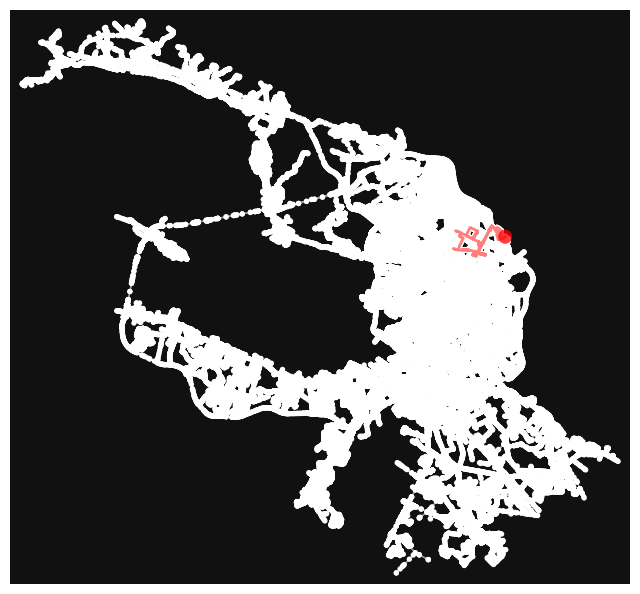

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [126]:
ox.plot_graph_route(graph, final_path, route_color='red', route_linewidth=2)

In [125]:
# with open(save_dir / "boundaries.geojson", "w") as f:
#     f.write(shapely.to_geojson(boundaries))

# if "edges.geojson" not in os.listdir(save_dir):
with open(save_dir / "edges.geojson", "w") as f:
    f.write(edges.to_json())

# if "nodes.geojson" not in os.listdir(save_dir):
#     with open(save_dir / "nodes.geojson", "w") as f:
#         f.write(nodes.to_json())

# near_points.to_file(save_dir/"points.geojson", driver="GeoJSON")
# edges.to_file(save_dir/"edges.geojson", driver="GeoJSON")
# nodes.to_file(save_dir/"nodes.geojson", driver="GeoJSON")